In [1]:
import pandas as pd

### Load Data

In [2]:
data = pd.read_csv('dataset_pos_aromajaya.csv')
data.head()

,transaction_id,transaction_date,transaction_time,store_location,product_id,product_name,product_category,quantity,unit_price,tipe_order
0,TX27199,2026-02-21,21:09:47,Gading Serpong (Residential),107,Es Teh Manis,Non-Coffee,1,10000,Takeaway
1,TX15186,2026-04-03,08:35:03,sudirman (office),103,Café Latte,Coffee,2,30000,Takeaway
2,TX22510,2026-03-20,17:13:40,Gading Serpong (Residential),104,Matcha Latte,Non-Coffee,5,28000,Dine-in
3,TX27134,2026-06-20,15:32:30,Senopati (Hangout),107,Es Teh Manis,Non-Coffee,1,10000,Dine-in
4,TX35561,2026-02-21,18:57:17,Senopati (Hangout),102,Americano,Coffee,1,25000,Takeaway


### Data Info

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43867 entries, 0 to 43866
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    43867 non-null  object
 1   transaction_date  43867 non-null  object
 2   transaction_time  43867 non-null  object
 3   store_location    43859 non-null  object
 4   product_id        43867 non-null  int64 
 5   product_name      43867 non-null  object
 6   product_category  43867 non-null  object
 7   quantity          43867 non-null  int64 
 8   unit_price        43867 non-null  int64 
 9   tipe_order        43860 non-null  object
dtypes: int64(3), object(7)
memory usage: 3.3+ MB


### Handle Duplicate Data

In [4]:
print(f'Total duplicated data: {data.duplicated().sum()} row')

Total duplicated data: 35 row


In [5]:
# clean duplicated data
data = data.drop_duplicates()
print(f'Total duplicated data: {data.duplicated().sum()} row')

Total duplicated data: 0 row


### Normalization Categorical Data

In [6]:
data.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'store_location', 'product_id', 'product_name', 'product_category',
       'quantity', 'unit_price', 'tipe_order'],
      dtype='object')

In [7]:
data.store_location.unique()

array(['Gading Serpong (Residential)', 'sudirman (office)',
       'Senopati (Hangout)', 'Sudirman Office', 'Sudirman (Office)',
       'Senopati HANGOUT', nan], dtype=object)

In [8]:
clean_location = {
    'sudirman (office)':'Sudirman (Office)',
    'Sudirman Office':'Sudirman (Office)',
    'Senopati HANGOUT':'Senopati (Hangout)'
}
data['store_location'] = data['store_location'].replace(clean_location)

In [9]:
print(f'location category after normalization: {data.store_location.unique()}')

location category after normalization: ['Gading Serpong (Residential)' 'Sudirman (Office)' 'Senopati (Hangout)'
 nan]


In [10]:
data.product_name.unique()

array(['Es Teh Manis', 'Café Latte', 'Matcha Latte', 'Americano',
       'Croissant Cokelat', 'Es Kopi Susu Gula Aren',
       'Roti Bakar Bandung', 'Kentang Goreng'], dtype=object)

In [11]:
data.product_category.unique()

array(['Non-Coffee', 'Coffee', 'Bakery', 'Snack'], dtype=object)

In [12]:
data.tipe_order.unique()

array(['Takeaway', 'Dine-in', 'DINE IN', 'takeaway', nan], dtype=object)

In [13]:
clean_tipe_order = {
    'takeaway':'Takeaway',
    'DINE IN':'Dine-in'
}

data.tipe_order = data.tipe_order.replace(clean_tipe_order)

In [14]:
print(f'order type after normalization: {data.tipe_order.unique()}')

order type after normalization: ['Takeaway' 'Dine-in' nan]


### Handle Missing Value

In [15]:
data.isna().sum()

transaction_id      0
transaction_date    0
transaction_time    0
store_location      8
product_id          0
product_name        0
product_category    0
quantity            0
unit_price          0
tipe_order          7
dtype: int64

In [16]:
data.store_location.value_counts()

store_location
Sudirman (Office)               20536
Senopati (Hangout)              15197
Gading Serpong (Residential)     8091
Name: count, dtype: int64

In [17]:
data['store_location'] = data['store_location'].fillna(data['store_location'].mode()[0])

print(f'Null location data after cleaning: {data.store_location.isna().sum()}')

Null location data after cleaning: 0


In [18]:
data.tipe_order = data.tipe_order.fillna(data.tipe_order.mode()[0])

print(f'Null order type data after cleaning: {data.tipe_order.isna().sum()}')

Null order type data after cleaning: 0


### Handling Outlier 

<Axes: >

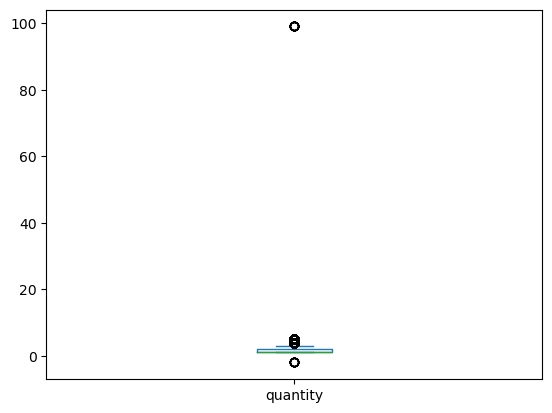

In [19]:
data.quantity.plot(kind='box')

In [20]:
data.quantity.unique()

array([ 1,  2,  5,  4,  3, 99, -2])

In [21]:
data = data[(data.quantity >= 1) & (data.quantity <= 5)]

In [22]:
data.quantity.unique()

array([1, 2, 5, 4, 3])

### Normalization Datetime Data

In [23]:
data['transaction_date'] = pd.to_datetime(data['transaction_date'], format='%Y-%m-%d', errors='coerce')
data['transaction_time'] = pd.to_datetime(data['transaction_time'], format='%H:%M:%S', errors='coerce')

### Feature Engineering

In [24]:
# total omzet
data['omzet'] = data['quantity'] * data['unit_price']

# Month Column
data['month'] = data['transaction_date'].dt.month_name()

# Day Column
data['day'] = data['transaction_date'].dt.day_name()

# Hour Column
data['hour'] = data['transaction_time'].dt.hour

#drop transaction_time
data = data.drop(columns=['transaction_time'])

### Check Consistency Data

In [25]:
data.groupby(['product_id', 'product_name', 'product_category', 'unit_price'])['omzet'].sum().sort_values(ascending=False).reset_index()

,product_id,product_name,product_category,unit_price,omzet
0,101,Es Kopi Susu Gula Aren,Coffee,22000,469238000
1,102,Americano,Coffee,25000,304625000
2,103,Café Latte,Coffee,30000,217800000
3,104,Matcha Latte,Non-Coffee,28000,140448000
4,105,Croissant Cokelat,Bakery,25000,107400000
5,107,Es Teh Manis,Non-Coffee,10000,68370000
6,106,Roti Bakar Bandung,Snack,18000,68094000
7,108,Kentang Goreng,Snack,20000,12280000


### save as csv

In [26]:
data.to_csv('cleaned_data.csv', index=False)
print('sucess')

sucess


In [27]:
data.head(3)

,transaction_id,transaction_date,store_location,product_id,product_name,product_category,quantity,unit_price,tipe_order,omzet,month,day,hour
0,TX27199,2026-02-21,Gading Serpong (Residential),107,Es Teh Manis,Non-Coffee,1,10000,Takeaway,10000,February,Saturday,21
1,TX15186,2026-04-03,Sudirman (Office),103,Café Latte,Coffee,2,30000,Takeaway,60000,April,Friday,8
2,TX22510,2026-03-20,Gading Serpong (Residential),104,Matcha Latte,Non-Coffee,5,28000,Dine-in,140000,March,Friday,17
